In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_adi = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_adi)
model = AutoModelForCausalLM.from_pretrained(
    model_adi,
    torch_dtype="auto",
    device_map="auto"
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [2]:
# 1. Araç: Hesap makinesi
def hesap_makinesi(ifade):
    try:
        izinli = "0123456789+-*/(). "
        if all(k in izinli for k in ifade):
            return str(eval(ifade))
        return "Geçersiz ifade"
    except Exception as e:
        return f"Hata: {e}"

# 2. Araç: Kelime sayacı
def kelime_say(metin):
    return str(len(metin.split()))

# Araçları tek bir sözlükte topla (ajan buradan seçecek)
araclar = {
    "hesapla": hesap_makinesi,
    "kelime_say": kelime_say,
}

In [3]:
sistem_talimati = """Sen yardımcı bir asistansın. İki aracın var:

1. hesapla → matematik işlemleri için. Kullanımı:
   ARAÇ: hesapla | <matematik ifadesi>
   Örnek: ARAÇ: hesapla | 245 * 17

2. kelime_say → bir metindeki kelime sayısını bulmak için. Kullanımı:
   ARAÇ: kelime_say | <metin>
   Örnek: ARAÇ: kelime_say | bugün hava çok güzel

Kurallar:
- Bir araç gerekiyorsa YALNIZCA yukarıdaki formatta yaz (araç adı | girdi).
- Araç gerekmiyorsa doğrudan şöyle cevap ver:
  CEVAP: <cevabın>
"""

In [4]:
def modele_sor(mesajlar):
    metin = tokenizer.apply_chat_template(
        mesajlar, tokenize=False, add_generation_prompt=True
    )
    girdiler = tokenizer(metin, return_tensors="pt").to(model.device)
    with torch.no_grad():
        cikti = model.generate(**girdiler, max_new_tokens=200)
    yeni = cikti[0][girdiler["input_ids"].shape[1]:]
    return tokenizer.decode(yeni, skip_special_tokens=True).strip()

In [5]:
def ajan(soru, max_adim=4):
    mesajlar = [
        {"role": "system", "content": sistem_talimati},
        {"role": "user", "content": soru},
    ]

    for adim in range(max_adim):
        cevap = modele_sor(mesajlar)
        print(f"[Adım {adim+1}] Model: {cevap}")

        if cevap.startswith("ARAÇ:"):
            # "ARAÇ: hesapla | 245 * 17" formatını parçala
            komut = cevap.replace("ARAÇ:", "").strip()
            arac_adi, _, girdi = komut.partition("|")
            arac_adi = arac_adi.strip()
            girdi = girdi.strip()

            if arac_adi in araclar:
                sonuc = araclar[arac_adi](girdi)
                print(f"        → '{arac_adi}' aracı çalıştı: {girdi} = {sonuc}")
                mesajlar.append({"role": "assistant", "content": cevap})
                mesajlar.append({"role": "user",
                                 "content": f"Araç sonucu: {sonuc}. Şimdi CEVAP ver."})
            else:
                return f"Bilinmeyen araç: {arac_adi}"

        elif cevap.startswith("CEVAP:"):
            return cevap.replace("CEVAP:", "").strip()

        else:
            return cevap

    return "Adım limiti doldu."

In [6]:
print("Sonuç:", ajan("Bir kutuda 24 kalem var. 17 kutu alırsam kaç kalemim olur?"))
print("="*60)
print("Sonuç:", ajan("'yapay zeka öğrenmek gerçekten çok keyifli' cümlesinde kaç kelime var?"))
print("="*60)
print("Sonuç:", ajan("Türkiye'nin başkenti neresidir?"))
print("="*60)
print("Sonuç:", ajan("847 çarpı 236 kaç eder?"))

[Adım 1] Model: ARAÇ: hesapla | 24 + 17
        → 'hesapla' aracı çalıştı: 24 + 17 = 41
[Adım 2] Model: CEVAP: 41 kalem var.
Sonuç: 41 kalem var.
[Adım 1] Model: CEVAP: 9 kelime var.
Sonuç: 9 kelime var.
[Adım 1] Model: CEVAP: Ankara'dır.
Sonuç: Ankara'dır.
[Adım 1] Model: ARAÇ: hesapla | 847 * 236
        → 'hesapla' aracı çalıştı: 847 * 236 = 199892
[Adım 2] Model: CEVAP: 199892
Sonuç: 199892


In [7]:
# Beklenen cevabı bilinen test soruları (soru, doğru_cevap, araç_gerekli_mi)
test_seti = [
    ("24 çarpı 17 kaç eder?", "408", True),
    ("100 ile 250'yi topla.", "350", True),
    ("847 çarpı 236 kaç eder?", "199892", True),
    ("'yapay zeka çok keyifli' cümlesinde kaç kelime var?", "3", True),
    ("'bugün hava gerçekten çok güzel' kaç kelime?", "5", True),
    ("Türkiye'nin başkenti neresidir?", "Ankara", False),
    ("Bir haftada kaç gün vardır?", "7", False),
]

sonuclar = []
for soru, dogru, arac_gerekli in test_seti:
    tahmin = ajan(soru)
    # Cevap doğru mu? (doğru cevap, tahminin içinde geçiyorsa doğru say)
    dogru_mu = dogru.lower() in tahmin.lower()
    sonuclar.append({
        "soru": soru,
        "dogru_cevap": dogru,
        "ajan_cevabi": tahmin,
        "dogru_mu": dogru_mu,
        "kategori": "Araçlı" if arac_gerekli else "Araçsız"
    })
    print(f"{'✅' if dogru_mu else '❌'} Soru: {soru}")
    print(f"   Beklenen: {dogru}  |  Ajan: {tahmin}\n")

# Genel doğruluk
dogru_sayisi = sum(1 for s in sonuclar if s["dogru_mu"])
toplam = len(sonuclar)
print("="*55)
print(f"GENEL DOĞRULUK: {dogru_sayisi}/{toplam} = %{dogru_sayisi/toplam*100:.1f}")

[Adım 1] Model: ARAÇ: hesapla | 24 * 17
        → 'hesapla' aracı çalıştı: 24 * 17 = 408
[Adım 2] Model: CEVAP: 408
✅ Soru: 24 çarpı 17 kaç eder?
   Beklenen: 408  |  Ajan: 408

[Adım 1] Model: CEVAP: 350
✅ Soru: 100 ile 250'yi topla.
   Beklenen: 350  |  Ajan: 350

[Adım 1] Model: ARAÇ: hesapla | 847 * 236
        → 'hesapla' aracı çalıştı: 847 * 236 = 199892
[Adım 2] Model: CEVAP: 199892
✅ Soru: 847 çarpı 236 kaç eder?
   Beklenen: 199892  |  Ajan: 199892

[Adım 1] Model: CEVAP: 3 kelime(var)
✅ Soru: 'yapay zeka çok keyifli' cümlesinde kaç kelime var?
   Beklenen: 3  |  Ajan: 3 kelime(var)

[Adım 1] Model: CEVAP: 13 kelime
❌ Soru: 'bugün hava gerçekten çok güzel' kaç kelime?
   Beklenen: 5  |  Ajan: 13 kelime

[Adım 1] Model: CEVAP: Ankara'dır.
✅ Soru: Türkiye'nin başkenti neresidir?
   Beklenen: Ankara  |  Ajan: Ankara'dır.

[Adım 1] Model: CEVAP: Hafta günü 7 gün vardır.
✅ Soru: Bir haftada kaç gün vardır?
   Beklenen: 7  |  Ajan: Hafta günü 7 gün vardır.

GENEL DOĞRULUK: 6/7 = %85

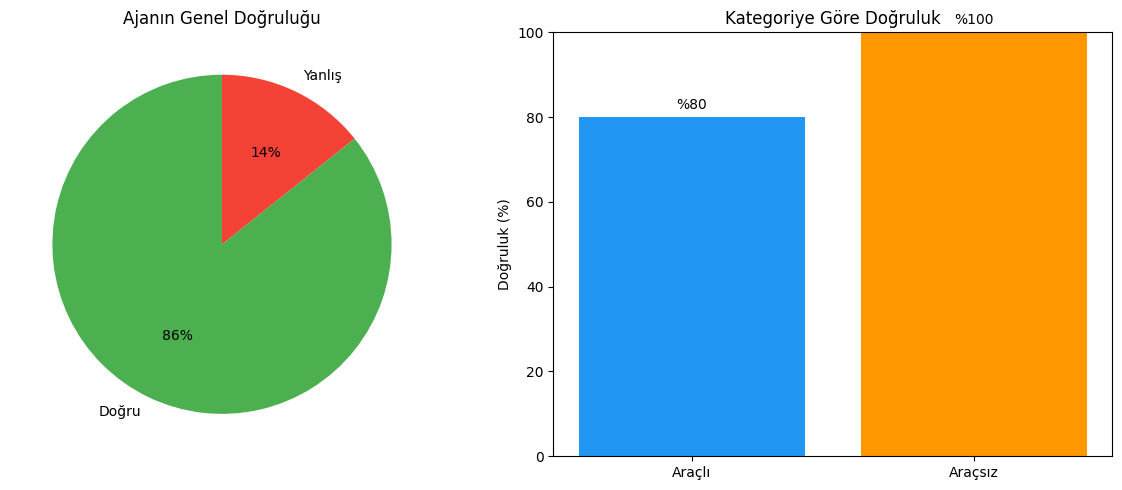

In [8]:
import matplotlib.pyplot as plt

# 1) Genel doğru/yanlış dağılımı (pasta grafik)
dogru_sayisi = sum(1 for s in sonuclar if s["dogru_mu"])
yanlis_sayisi = len(sonuclar) - dogru_sayisi

fig, eksen = plt.subplots(1, 2, figsize=(12, 5))

eksen[0].pie([dogru_sayisi, yanlis_sayisi],
             labels=["Doğru", "Yanlış"],
             colors=["#4CAF50", "#F44336"],
             autopct="%1.0f%%", startangle=90)
eksen[0].set_title("Ajanın Genel Doğruluğu")

# 2) Kategoriye göre doğruluk (çubuk grafik: Araçlı vs Araçsız)
kategoriler = ["Araçlı", "Araçsız"]
oranlar = []
for kat in kategoriler:
    grup = [s for s in sonuclar if s["kategori"] == kat]
    dogru = sum(1 for s in grup if s["dogru_mu"])
    oranlar.append(dogru / len(grup) * 100 if grup else 0)

eksen[1].bar(kategoriler, oranlar, color=["#2196F3", "#FF9800"])
eksen[1].set_title("Kategoriye Göre Doğruluk")
eksen[1].set_ylabel("Doğruluk (%)")
eksen[1].set_ylim(0, 100)
for i, oran in enumerate(oranlar):
    eksen[1].text(i, oran + 2, f"%{oran:.0f}", ha="center")

plt.tight_layout()
plt.show()

# AI Agent'ın Geliştirilmesi: Çoklu Araç + Doğruluk Değerlendirmesi

Bu çalışmada, önceki tek araçlı AI Agent'ı iki yönde geliştirdik: ajana **ikinci bir araç** eklendi (böylece hangi aracı kullanacağına kendi karar verebiliyor) ve ajanın performansı bir **doğruluk (accuracy) ölçümü** ile sayısal, ardından **grafiklerle** görsel olarak değerlendirildi.

## Amaç

- Ajana birden fazla araç tanımlayarak, doğru aracı seçme (karar verme) yeteneğini görünür kılmak.
- Ajanın cevaplarını beklenen doğru cevaplarla karşılaştırıp doğruluk oranını ölçmek.
- Sonuçları grafiklerle görselleştirmek.

## Kullanılan Araçlar

- **Qwen2.5-1.5B-Instruct** — talimat takip eden, üretken (generative) sohbet modeli.
- **Transformers (AutoModelForCausalLM)** — metin üreten model sınıfı.
- **matplotlib** — sonuçları grafikle çizmek için kullanılan görselleştirme kütüphanesi.

## Ajana Eklenen Araçlar

Ajan artık iki araca sahip ve gelen soruya göre bunlardan birini seçiyor (ya da hiç kullanmıyor):

| Araç | Ne işe yarar | Ne zaman seçilir |
|------|--------------|-------------------|
| `hesapla` | Matematik işlemleri | Sayısal/hesaplama gerektiren sorular |
| `kelime_say` | Metindeki kelime sayısı | Metin/kelime ile ilgili sorular |
| (araç yok) | — | Genel kültür soruları (doğrudan cevap) |

Araçlar bir sözlükte (isim → fonksiyon) toplandı; ajan bir araç seçtiğinde ilgili fonksiyon bu sözlükten bulunup çalıştırılıyor. Bu yapı sayesinde yeni bir araç eklemek, sözlüğe tek bir satır eklemek kadar kolay.

## Model–Araç İletişimi

Ajan, kullanmak istediği aracı basit bir formatla belirtiyor:
- `ARAÇ: <araç adı> | <girdi>` → belirtilen aracı çağır.
- `CEVAP: <metin>` → nihai cevabı ver.

`|` işareti, araç adını girdisinden ayırıyor (örn. `hesapla | 245 * 17`). Böylece ajan hem "araç gerekli mi?" hem de "hangi araç?" sorularına birlikte karar veriyor.

## Değerlendirme Yöntemi

Beklenen cevabı önceden bilinen bir **test seti** hazırlandı (araçlı ve araçsız sorular karışık). Ajan her soruyu cevapladı; beklenen doğru cevabın, ajanın cevabının içinde geçip geçmediğine bakılarak her cevap doğru/yanlış olarak işaretlendi. Ardından genel doğruluk oranı hesaplandı ve iki grafikle gösterildi:

- **Pasta grafik:** ajanın genel doğru/yanlış dağılımı.
- **Çubuk grafik:** araçlı ve araçsız sorulardaki başarının ayrı ayrı karşılaştırması.

## Çıkarılan Ders

Bir agent'ı asıl güçlü kılan şey, birden fazla araç arasından **doğru olanı seçebilme** yeteneğidir; tek araçta bu karar görünmez, çoklu araçta ise ajanın "zekası" ortaya çıkar. Ayrıca, bir sistemi sadece kurmak yetmez; **ölçmek** de gerekir. Doğruluk hesaplama ve görselleştirme sayesinde ajanın nerede iyi, nerede zayıf olduğu (örneğin araçlı sorularda mı yoksa araçsız sorularda mı daha başarılı) somut biçimde görülebiliyor. Küçük modellerde bazı cevapların yanlış çıkması normaldir ve bu, değerlendirmenin neden gerekli olduğunu da gösterir.